# How Does Global AI Adoption Rate Compare with Productivity Change?
### ENGE707: Data Engineering and Machine Learning Assignment

Suemon Kwok (14883335), Quentin Masoe (23191960), Avathanshu Bhat (23227963)

**Dataset:** Global AI Adoption and Workforce Impact Dataset (`ai_company_adoption.csv`), Kaggle, CC0 - 150,000 quarterly company records, 43 columns, Q1 2023 to Q4 2026.
Link: https://www.kaggle.com/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset

**Research question:** how does a company's AI adoption rate compare with the productivity change it subsequently reports?

**Scope note.** An earlier draft of this project looked at several AI-related variables at once (maturity, ethics governance, workforce displacement, investment). Following lecturer feedback, the project was narrowed to a single comparison so each pipeline stage could be examined in depth:

| Role | Column | Meaning |
|---|---|---|
| Focus variable 1 | `ai_adoption_rate` | % of a company's operations/processes that use AI |
| Focus variable 2 | `productivity_change_percent` | % change in productivity subsequently reported |

This notebook covers the four Phase 1 tasks: problem and dataset selection, data acquisition and inspection, data cleansing and transformation, and exploratory data analysis.

In [35]:
import os
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

## Task 1 - Problem Definition and Dataset Selection

- **Source:** Global AI Adoption and Workforce Impact Dataset (Kaggle, CC0), provided as `ai_company_adoption.csv`.
- **Structure:** tabular, alphanumeric, 150,000 rows x 43 columns — satisfies the assignment's requirement of more than 20 and fewer than 300 features.
- **Unit of observation:** one row = one company's survey response for one quarter (a company can appear multiple times, once per quarter, identified by `company_id`).
- **Stakeholders:** executives deciding AI budgets, technology investment committees, and policymakers (e.g. the OECD) who need evidence of whether AI adoption is converting into measurable productivity gains.

## Task 2 - Data Acquisition, Inspection and Documentation

### 2.1 Loading and structural inspection

In [36]:
# Load the dataset (extract from archive.zip first if the CSV isn't already alongside this notebook)
CSV_NAME = "ai_company_adoption.csv"
ZIP_NAME = "archive.zip"

if not os.path.exists(CSV_NAME) and os.path.exists(ZIP_NAME):
    with zipfile.ZipFile(ZIP_NAME) as z:
        z.extractall(".")

df = pd.read_csv(CSV_NAME)

print("Shape:", df.shape)
df.head()

Shape: (150000, 43)


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,company_founding_year,company_age,company_age_group,ai_adoption_rate,ai_adoption_stage,years_using_ai,ai_primary_tool,num_ai_tools_used,ai_use_case,ai_projects_active,ai_training_hours,ai_budget_percentage,ai_maturity_score,ai_failure_rate,ai_investment_per_employee,regulatory_compliance_score,data_privacy_level,ai_ethics_committee,ai_risk_management_score,remote_work_percentage,employee_satisfaction_score,task_automation_rate,time_saved_per_week,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,30.57,pilot,3,ChatGPT,1,Customer Support,3,20.94,6.54,0.224,35.22,55392.29,60,Medium,No,60,14.55,6.95,19.47,6.44,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,27.25,pilot,4,ChatGPT,3,Software Development,0,23.10,5.81,0.174,24.65,49210.79,68,High,No,53,50.25,5.16,26.24,8.92,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,31.54,pilot,2,Custom Internal AI,3,HR Automation,3,12.29,12.39,0.266,36.51,105011.76,66,High,No,53,41.70,4.57,22.24,7.59,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,1994,29,16-30 years,11.02,pilot,2,Custom Internal AI,1,Software Development,2,11.31,3.20,0.123,33.30,27157.71,64,High,No,44,28.10,5.33,2.87,3.16,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,1994,30,16-30 years,33.39,pilot,7,ChatGPT,3,Customer Support,5,35.17,9.98,0.363,19.83,84622.90,68,High,Yes,77,29.93,6.00,18.44,7.03,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150000 non-null  int64  
 1   company_id                   150000 non-null  str    
 2   survey_year                  150000 non-null  int64  
 3   quarter                      150000 non-null  str    
 4   country                      150000 non-null  str    
 5   region                       150000 non-null  str    
 6   industry                     150000 non-null  str    
 7   company_size                 150000 non-null  str    
 8   num_employees                150000 non-null  int64  
 9   annual_revenue_usd_millions  150000 non-null  float64
 10  company_founding_year        150000 non-null  int64  
 11  company_age                  150000 non-null  int64  
 12  company_age_group            150000 non-null  str    
 13  ai_adoptio

In [38]:
# quarter takes only four repeating values, so it is converted to a category dtype;
# the other categorical columns sit outside the narrowed two-variable comparison
df["quarter"] = df["quarter"].astype("category")

print("Column dtype counts:")
print(df.dtypes.value_counts())

print("\nColumns spanning:", df["country"].nunique(), "countries and",
      df["industry"].nunique(), "industries")
print("Company size categories:", df["company_size"].unique().tolist())

Column dtype counts:
float64     15
int64       14
str         13
category     1
Name: count, dtype: int64

Columns spanning: 30 countries and 9 industries
Company size categories: ['Startup', 'Enterprise', 'SME']


The dataset spans 30 countries and 9 industries and separates companies into three size categories (Startup, SME, Enterprise). This categorical variety is not used directly in the narrowed two-variable comparison, but it confirms the dataset covers a broad population of companies rather than a narrow or unrepresentative sample.

In [39]:
df_original = df.copy(deep=True)

print("Records:", df_original.shape[0])
print("Columns:", df_original.shape[1])

print("\nFirst look at the two focus columns:")
print(df_original[["ai_adoption_rate", "productivity_change_percent"]].describe())

Records: 150000
Columns: 43

First look at the two focus columns:
       ai_adoption_rate  productivity_change_percent
count     150000.000000                150000.000000
mean          36.414726                     9.266996
std           14.544096                     5.637067
min            0.000000                     0.000000
25%           26.430000                     5.070000
50%           36.320000                     9.060000
75%           46.200000                    13.120000
max          100.000000                    34.360000


### 2.2 Data-quality inspection of the focus variables

In [40]:
focus = ["ai_adoption_rate", "productivity_change_percent"]

# Missing values
missing_focus = df_original[focus].isna().sum()
print("Missing values in the focus columns:")
print(missing_focus)
if missing_focus.sum() == 0:
    print("-> Confirmed: no missing data in either focus column.")

# Duplicate rows / duplicate response IDs
print("\nNumber of fully duplicate rows:", df_original.duplicated().sum())
print("Number of duplicate response_id values:", df_original["response_id"].duplicated().sum())

# Value ranges
print("\nMinimum and maximum values:")
print(df_original[focus].agg(["min", "max"]).T)

Missing values in the focus columns:
ai_adoption_rate               0
productivity_change_percent    0
dtype: int64
-> Confirmed: no missing data in either focus column.

Number of fully duplicate rows: 0
Number of duplicate response_id values: 0

Minimum and maximum values:
                             min     max
ai_adoption_rate             0.0  100.00
productivity_change_percent  0.0   34.36


## Task 3 - Data Cleansing and Transformation

### 3.1 Cleaning

In [41]:
def clean_data(data):
    clean = data.copy(deep=True)

    # Safeguard: drop any record with a missing or out-of-range focus value
    invalid_record = (
        clean["ai_adoption_rate"].isna()
        | clean["productivity_change_percent"].isna()
        | ~clean["ai_adoption_rate"].between(0, 100)
    )
    print("Invalid/missing records removed:", invalid_record.sum())

    clean = clean.loc[~invalid_record].copy()
    clean = clean.drop_duplicates()

    # Narrow the working frame down to the single comparison, plus lightweight identifiers
    keep_cols = ["company_id", "survey_year", "quarter",
                 "ai_adoption_rate", "productivity_change_percent"]
    clean = clean[keep_cols].reset_index(drop=True)
    return clean


df_clean = clean_data(df_original)

print("\nOriginal shape:", df_original.shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", len(df_original) - len(df_clean))
print("Duplicate rows remaining:", df_clean.duplicated().sum())

Invalid/missing records removed: 0

Original shape: (150000, 43)
Cleaned shape: (150000, 5)
Rows removed: 0
Duplicate rows remaining: 0


### 3.2 Outlier investigation (interquartile range method)

In [42]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    below = (series < lower).sum()
    above = (series > upper).sum()
    return below, above, lower, upper


for col in focus:
    below, above, lower, upper = iqr_outliers(df_clean[col])
    pct = (below + above) / len(df_clean) * 100
    print(f"{col}: {below} below lower fence, {above} above upper fence "
          f"({pct:.2f}% of {len(df_clean)} records) | fence = [{lower:.2f}, {upper:.2f}]")

ai_adoption_rate: 0 below lower fence, 504 above upper fence (0.34% of 150000 records) | fence = [-3.23, 75.86]
productivity_change_percent: 0 below lower fence, 529 above upper fence (0.35% of 150000 records) | fence = [-7.00, 25.20]


## Task 4 - Exploratory Data Analysis and Visualisation

### 4.1 Descriptive statistics

In [43]:
desc = df_clean[focus].describe().round(2)
skew = df_clean[focus].skew().round(2)
print(desc)
print("\nSkewness:")
print(skew)

       ai_adoption_rate  productivity_change_percent
count         150000.00                    150000.00
mean              36.41                         9.27
std               14.54                         5.64
min                0.00                         0.00
25%               26.43                         5.07
50%               36.32                         9.06
75%               46.20                        13.12
max              100.00                        34.36

Skewness:
ai_adoption_rate               0.06
productivity_change_percent    0.30
dtype: float64


### 4.2 Distribution analysis

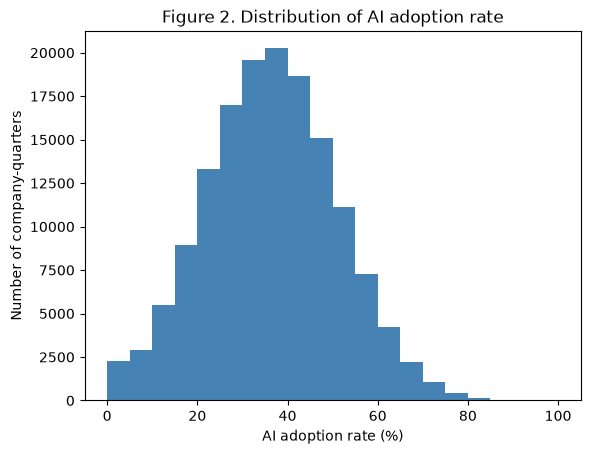

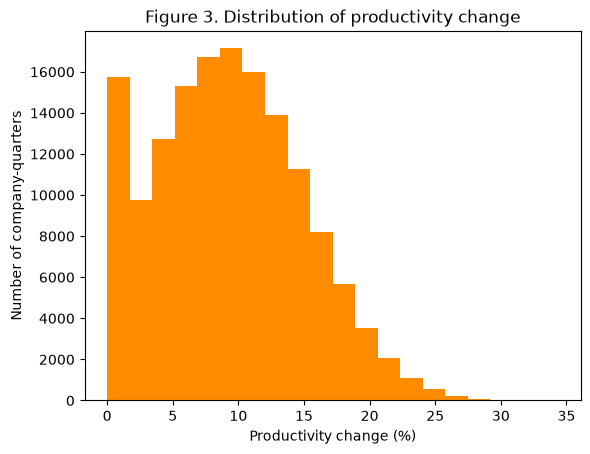

In [44]:
plt.hist(df_clean["ai_adoption_rate"], bins=20, color="steelblue")
plt.xlabel("AI adoption rate (%)")
plt.ylabel("Number of company-quarters")
plt.title("Figure 2. Distribution of AI adoption rate")
plt.show()

plt.hist(df_clean["productivity_change_percent"], bins=20, color="darkorange")
plt.xlabel("Productivity change (%)")
plt.ylabel("Number of company-quarters")
plt.title("Figure 3. Distribution of productivity change")
plt.show()

### 4.3 Outlier analysis

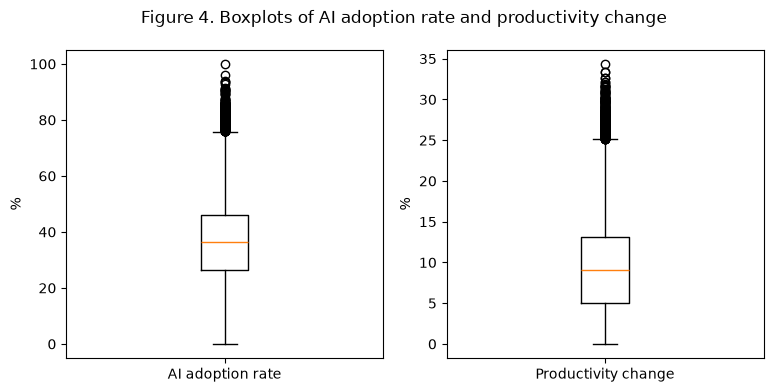

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].boxplot(df_clean["ai_adoption_rate"], tick_labels=["AI adoption rate"])
axes[0].set_ylabel("%")
axes[1].boxplot(df_clean["productivity_change_percent"], tick_labels=["Productivity change"])
axes[1].set_ylabel("%")
plt.suptitle("Figure 4. Boxplots of AI adoption rate and productivity change")
plt.show()

### 4.4 Relationship analysis

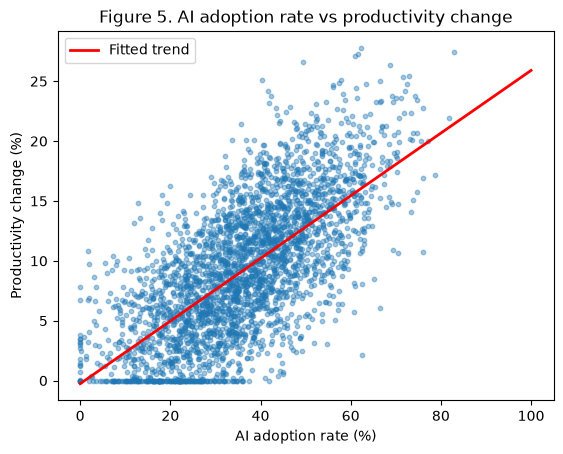

Pearson correlation coefficient: 0.675
Fitted line: productivity_change_percent = 0.2616 * ai_adoption_rate + -0.26


In [46]:
x = df_clean["ai_adoption_rate"]
y = df_clean["productivity_change_percent"]

# Sample for plotting only (150,000 points is too dense to read); all statistics below use the full data
sample = df_clean.sample(n=3000, random_state=42)

plt.scatter(sample["ai_adoption_rate"], sample["productivity_change_percent"], alpha=0.4, s=10)

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, slope * x_line + intercept, color="red", linewidth=2, label="Fitted trend")

plt.xlabel("AI adoption rate (%)")
plt.ylabel("Productivity change (%)")
plt.title("Figure 5. AI adoption rate vs productivity change")
plt.legend()
plt.show()

pearson_r = x.corr(y)
print(f"Pearson correlation coefficient: {pearson_r:.3f}")
print(f"Fitted line: productivity_change_percent = {slope:.4f} * ai_adoption_rate + {intercept:.2f}")

**Zero-productivity subgroup:**

In [47]:
zero_prod = df_clean[df_clean["productivity_change_percent"] == 0]
print("Records with exactly 0% productivity change:", len(zero_prod),
      f"({len(zero_prod) / len(df_clean) * 100:.1f}% of the cleaned dataset)")
print("\nAI adoption rate within this zero-productivity subgroup:")
print(zero_prod["ai_adoption_rate"].describe().round(2))
print("\nAI adoption rate across the full cleaned dataset (for comparison):")
print(df_clean["ai_adoption_rate"].describe().round(2))

Records with exactly 0% productivity change: 9027 (6.0% of the cleaned dataset)

AI adoption rate within this zero-productivity subgroup:
count    9027.00
mean       18.39
std        10.33
min         0.00
25%        10.92
50%        18.44
75%        25.54
max        60.45
Name: ai_adoption_rate, dtype: float64

AI adoption rate across the full cleaned dataset (for comparison):
count    150000.00
mean         36.41
std          14.54
min           0.00
25%          26.43
50%          36.32
75%          46.20
max         100.00
Name: ai_adoption_rate, dtype: float64


### 4.5 Grouped comparison

ai_adoption_rate
Low        5.62
Medium    11.63
High      18.97
Name: productivity_change_percent, dtype: float64


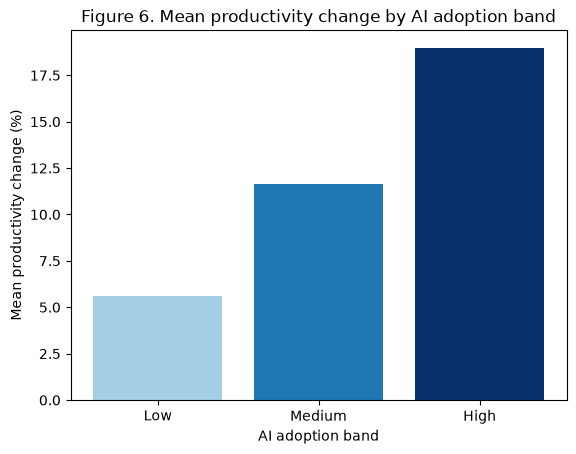

In [48]:
bins = [-0.01, 33.3, 66.6, 100]
labels = ["Low", "Medium", "High"]
adoption_band = pd.cut(df_clean["ai_adoption_rate"], bins=bins, labels=labels)

band_means = df_clean.groupby(adoption_band, observed=True)["productivity_change_percent"].mean()
print(band_means.round(2))

plt.bar(band_means.index.astype(str), band_means.values, color=["#a6cee3", "#1f78b4", "#08306b"])
plt.xlabel("AI adoption band")
plt.ylabel("Mean productivity change (%)")
plt.title("Figure 6. Mean productivity change by AI adoption band")
plt.show()

### 4.6 Correlation heatmap

                             ai_adoption_rate  productivity_change_percent
ai_adoption_rate                        1.000                        0.675
productivity_change_percent             0.675                        1.000


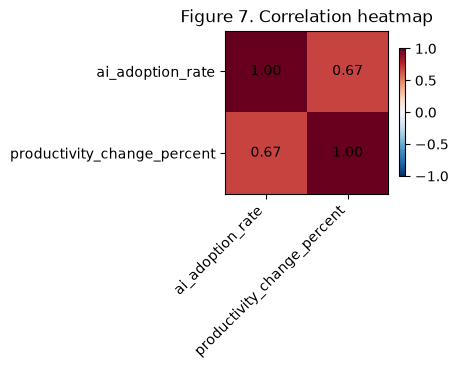

In [50]:
corr_matrix = df_clean[focus].corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(focus)))
ax.set_yticks(range(len(focus)))
ax.set_xticklabels(focus, rotation=45, ha="right")
ax.set_yticklabels(focus)
for i in range(len(focus)):
    for j in range(len(focus)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center")
ax.set_title("Figure 7. Correlation heatmap")
fig.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()